In [2]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(".."))) # Project Root
from src.data.containers import Universe, HestonParams

import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import matplotlib.pyplot as plt
import yfinance as yf
import QuantLib as ql

from datetime import datetime
from __future__ import annotations
from typing import Optional, List, Tuple
from scipy.optimize import least_squares

# Functions

## From Heston Pipeline

In [3]:
# --- A) Get Option Chains -------------------------------------------------------------


def market_close_asof(date_local: pd.Timestamp, cal_code: str = "XNYS") -> list[pd.Timestamp]:
    """
    Return the most recent market-close timestamp in UTC following a given market calendar.

    Args:
        date_local (pd.Timestamp):  Find the most recent market-close as of this local timestamp.
        cal_code (str):             Code corresponding to market calendar, e.g. XNYS (NYSE), XNAS (NASDAQ), XLON, XETR.
    
    Returns:
        list[pd.Timestamp] constianing the dates of the two most recent market closes (tz-aware, UTC).
    """
    
    cal = mcal.get_calendar(cal_code)

    # Build a small date window around date of interest to locate prev/next sessions
    date_utc = date_local.tz_convert("UTC")
    start = (date_utc - pd.Timedelta(days = 10)).date()
    end = (date_utc + pd.Timedelta(days = 10)).date()

    # Full schedule with market_open/market_close in calendar's local timezone
    sched = cal.schedule(start_date = start, end_date = end)

    # Convert schedule times to UTC for robust comparisons
    sched_utc = sched.copy()
    sched_utc["market_open_utc"] = sched_utc["market_open"].dt.tz_convert("UTC")
    sched_utc["market_close_utc"] = sched_utc["market_close"].dt.tz_convert("UTC")
    past_closes = sched_utc[sched_utc["market_close_utc"] <= date_utc]["market_close_utc"]

    # Is the market open?
    date_str = date_utc.date().isoformat()
    date_row = sched_utc.loc[date_str] if date_str in sched_utc.index else None

    # Determine the most recent completed close
    if date_row is not None:
        use_today = (date_utc >= date_row["market_close_utc"])
        if use_today:
            most_recent_close = date_row["market_close_utc"]
            prev_close = past_closes.iloc[-2]
        else:
            most_recent_close = past_closes.iloc[-1]
            prev_close = past_closes.iloc[-2]
    else:
        most_recent_close = past_closes.iloc[-1]
        prev_close = past_closes.iloc[-2]
        
    return [most_recent_close, prev_close]

def continuous_rate_from_annual_percent(pct_yield: float) -> float:
    """Convert a quoted annualized percent yield to continuous compounding."""
    y = float(pct_yield) / 100.0
    return np.log(1.0 + max(y, 0.0))

def exp_option_chain(ticker: str, exp_chain: yf.ticker.Ticker, exp: str, df_rows: list[pd.DataFrame], 
                     as_of_date: pd.Timestamp, S: float, r: float, q: float) -> list[pd.DataFrame]:

    """
    Aggregate option chain for given ticker at specific expiration.

    Args:
        ticker (str):                   Stock ticker symbol.
        exp_chain (yf.ticker.Ticker):   Option chain object with two DataFrames, one containing all the call options data 
                                        for the selected expiration date and the other all the put options data.
        exp (str):                      Option expiration date as 'YYYY-MM-DD'.
        df_rows (list):                 List of option chain DataFrames.
        as_of_date (pd.Timestamp):      Today's date.
        S (float):                      Spot price.
        r (float):                      Risk-free rate.
        q (float):                      Dividend yield.

    Returns:
        list[pd.DataFrame] of option chain DataFrames with those corresponding to the expiration date of interest appended.
    """
    for option_type, option_df in [("call", exp_chain.calls), ("put", exp_chain.puts)]:
        
        if option_df is None or option_df.empty:
            continue
        
        tmp = option_df.copy()
        tmp["type"] = option_type
        tmp["symbol"] = ticker
        tmp["expiry"] = pd.to_datetime(exp, utc=True)
        tmp["date"] = as_of_date
        tmp["underlying"] = S
        tmp["rate"] = r
        tmp["div_yield"] = q

        # Parse lastTradeDate and compute quote age (hours)
        if "lastTradeDate" in tmp.columns:
            tmp["lastTradeDate"] = pd.to_datetime(tmp["lastTradeDate"], utc=True, errors="coerce")
            tmp["quote_age_hours"] = (tmp["date"] - tmp["lastTradeDate"]).dt.total_seconds().clip(lower = 0) / 3600.0
        else:
            tmp["lastTradeDate"] = pd.NaT
            tmp["quote_age_hours"] = np.nan

        tmp.rename(columns={"impliedVolatility": "iv_mkt",
                            "lastPrice": "last"}, inplace=True)
        cols = ["contractSymbol", "date", "expiry", "symbol", "type", "inTheMoney", "strike", "bid", "ask", "last", 
                "underlying", "iv_mkt", "rate", "div_yield", "volume", "openInterest", "lastTradeDate", "quote_age_hours"]
        tmp = tmp[[c for c in cols if c in tmp.columns]]
        df_rows.append(tmp)
    
    return df_rows

def option_chains(ticker: str, market_cal: str, n_exp: int, as_of: str | None = None) -> pd.DataFrame: 
    """
    Get options chain for given ticker.

    Args:
        ticker (str):       Stock ticker symbol.
        market_cal (str):   Code corresponding to market calendar, e.g. XNYS (NYSE), XNAS (NASDAQ), XLON, XETR.
        n_exp (int):        Number of expiries to include.
        as_of (str | None): Date as 'YYYY-MM-DD'. 

    Returns:
        pd.DataFrame: Option chains for all expirations and option types (calls & puts).
    """
    # Market-close timestamp
    if as_of is None:
        # Most recent market-close as of today
        now_utc = pd.Timestamp.now(tz = "UTC")
        [as_of, prev_close] = market_close_asof(now_utc, market_cal)
    else:
        # Market-close on given date
        date_utc = pd.Timestamp(as_of).tz_localize("UTC")
        date_utc = date_utc.normalize() + pd.Timedelta(hours = 23, minutes = 59)
        [as_of, prev_close] = market_close_asof(date_utc, market_cal)
    
    # Create ticker object
    tk = yf.Ticker(ticker)

    # Available option expiry dates
    opts = tk.options
    if len(opts) == 0:
        raise RuntimeError(f"No option expiries available from yfinance for {ticker} right now.")
    
    # List of n expiries at least a week out
    time_to_expiry = []
    for expiry_date in opts:
        t = int(max(1, (pd.to_datetime(expiry_date, utc = True) - as_of).days))
        if t >= 7:
            time_to_expiry.append(expiry_date)
    expiries = time_to_expiry[:n_exp]

    # Pull 1 day of price history
    hist = tk.history(start = prev_close, end = as_of)
    if hist.empty:
        raise RuntimeError(f"No price history returned for {ticker}.")
    
    # Use latest close as spot
    S0 = float(hist["Close"].iloc[-1])

    # Risk-Free Proxy: 13-Week T-Bill
    try:
        irx = yf.Ticker("^IRX").history(period="5d")["Close"].dropna().iloc[-1]
        r_cont = continuous_rate_from_annual_percent(irx)
    except Exception:
        r_cont = 0.02 # fallback
    
    # Dividend Yield Proxy: trailing 365-day dividends / spot
    try:
        divs = tk.dividends
        recent = divs[divs.index >= (as_of - pd.Timedelta(days=365))]
        # Sum the last 365 days of dividends and divide by spot
        q_cont = float(recent.sum() / S0) if not recent.empty else 0.0 # NOT continuous q but proxy for
    except Exception:
        q_cont = 0.0 # fallback
    
    # Aggregate option chains
    rows = []
    for exp in expiries:
        chain = tk.option_chain(exp)
        rows = exp_option_chain(ticker, chain, exp, rows, as_of, S0, r_cont, q_cont)    
    df = pd.concat(rows, ignore_index=True)

    # Compute mid price from bid/ask when both exist; otherwise fall back to last price
    df["mid"] = np.where(np.isfinite(df[["bid", "ask"]]).all(axis = 1), 0.5 * (df["bid"] + df["ask"]), df["last"])
    
    # Compute time to expiry in years using Actual/365
    df["T"] = (pd.to_datetime(df["expiry"]) - pd.to_datetime(df["date"])).dt.days.clip(lower = 0).astype(float) / 365.0

    return df


# Clean Data

def clean_data(df: pd.DataFrame, tick: float = 0.01, min_oi: int = 10, age_hours: int = 48) -> pd.DataFrame:
    """
    Clean data and remove invalid & illiquid quotes.
    
    Args:
        df (pd.DataFrame):  Option chains data.
        tick (float):       Minimum tick, 0.01 default for equity options. 
        min_oi (int):       Minimum open interest to identify illiquid quotes.
        age_hours (int):    Threshold to mark lastTradeDate as stale.

    Returns:
        pd.DataFrame containing only valid and liquid quotes from option chains data.
    """
    # Remove rows with non-positive prices/strikes or zero time
    df = df[(df["mid"] > 0) & (df["strike"] > 0) & (df["T"] > 0)]

    # Remove rows with missing IVs, bid or ask quotes
    df = df.dropna(subset = ["iv_mkt", "bid", "ask"])

    # Remove rows with obviously broken IVs: negative/zero, or absurdly high (> 500%)
    df.loc[df["iv_mkt"] <= 0, "iv_mkt"] = np.nan
    df.loc[df["iv_mkt"] > 5.0, "iv_mkt"] = np.nan
    df = df.dropna(subset = ["iv_mkt"]).reset_index(drop = True)

    # Identify invalid quotes: ask < bid, negative bid/ask, or zero book
    df["invalid_quote"] = ((df["ask"] < df["bid"]) | 
                           (df["bid"] < 0) | (df["ask"] <= 0) | 
                           ((df["bid"] == 0) & (df["ask"] == 0)))

    # Identify locked quotes with no liquidity: bid = ask & volume = 0 & very low OI
    df["locked_no_liquidity"] = ((df["ask"] - df["bid"] <= tick + 1e-12) & 
                                 (df["volume"].fillna(0) == 0) & 
                                 (df["openInterest"].fillna(0) < min_oi))
    
    # Identify stale quotes ("too old") that were last traded over age_hours since as_of
    df["stale_age"] = ((df["quote_age_hours"] > age_hours))

    # Drop these quotes
    df["drop"] = df[["invalid_quote", "locked_no_liquidity", "stale_age"]].any(axis=1)
    df = df[~df["drop"]]
    df = df.drop(columns=["invalid_quote", "locked_no_liquidity", "stale_age", "drop"])

    return df

def most_liquid_quotes(df: pd.DataFrame, spread_width: float = 0.25) -> pd.DataFrame:
    """
    Only keep the most liquid part of the option chains: ATM +/- 50%.
    
    Args:
        df (pd.DataFrame):      Option chains data.
        spread_width (float):   Width factor to maintain a reasonable bid–ask spread. 

    Returns:
        pd.DataFrame containing onlt the most liquid part of the option chains.
    """

    # Forward price
    df["F"] = df["underlying"] * np.exp((df["rate"] - df["div_yield"]) * df["T"])

    # Keep only strikes within +/-50% of forward
    df = df[(df["strike"] >= 0.5 * df["F"]) & (df["strike"] <= 1.5 * df["F"])]

    # Reasonable bid–ask spread
    df = df[((df["ask"] - df["bid"]) / df["mid"]) < spread_width]
    
    return df



# --- B) Fit Heston Stochastic Volatility Model (Risk-Neutral Measure) -----------------


def build_vanilla_instruments(df: pd.DataFrame, today: ql.Date) -> list[ql.VanillaOption]:
    """
    Args:
        df (pd.DataFrame):  Option chains data.
        today (ql.Date):    Evaluation date.

    Returns:
        list of ql.VanillaOption objects corresponding to options available in chains.
    """

    options = []
    for _, df_row in df.iterrows():
        
        # Maturity
        T_days = int(max(1, (pd.to_datetime(df_row["expiry"]) - pd.to_datetime(df_row["date"])).days))
        maturity = today + T_days  # or cal.advance(today, T_days, ql.Days)
        exercise = ql.EuropeanExercise(maturity)

        # Payoff
        payoff = ql.PlainVanillaPayoff(ql.Option.Call if str(df_row["type"]).lower().startswith('c') else ql.Option.Put, float(df_row["strike"]))
        
        # Option Specification
        opt = ql.VanillaOption(payoff, exercise)
        options.append(opt)
    
    return options

def bs_price_vega(df: pd.DataFrame, options: list[ql.VanillaOption], S_q: ql.QuoteHandle,
                  r_ts: ql.YieldTermStructureHandle, q_ts: ql.YieldTermStructureHandle) -> pd.DataFrame:
    """
    Compute the Black-Scholes-Merton option price & vega for each quote in the options chain.
    
    Args:
        df (pd.DataFrame):                      Option chains data.
        options (list[ql.VanillaOption]):       List of ql.VanillaOption objects corresponding to option chains.
        S_q (ql.QuoteHandle):                   Spot quote.
        r_ts (ql.YieldTermStructureHandle):     Risk-free curve.
        q_ts (ql.YieldTermStructureHandle):     Dividend curve.
    
    Returns:
        pd.DataFrame with the option chains data and two new columns containing the Black-Scholes-Merton 
        option price ("bs_price") and corresponding vega ("vega") for each option.
    """

    bs_prices = []
    bs_vegas  = []
    bs_iv = []

    df = df.reset_index()
    for i, df_row in df.iterrows():

        # Build Volatility Curve
        sigma = float(df_row["iv_mkt"])
        vol_curve = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(0, ql.TARGET(), sigma, ql.Actual365Fixed()))

        # Build Black-Scholes-Merton process
        process = ql.BlackScholesMertonProcess(S_q, q_ts, r_ts, vol_curve)
        
        # Corresponding VanillaOption object
        option = options[i]

        # Black-Scholes analytic pricing engine
        engine = ql.AnalyticEuropeanEngine(process)
        option.setPricingEngine(engine)

        # Compute option price & vega
        bs_prices.append(option.NPV())
        bs_vegas.append(option.vega())

    df["bs_price"] = bs_prices
    df["vega"] = bs_vegas

    return df


# Calibration Weighting

def inverse_variance_weighting(bid: float, ask: float, S: float, K: float, T: float, r: float, q: float, iv: float, vega: float,
                               min_tick: float = 0.01, min_half_spread_iv: float = 0.0025, min_vega: float = 1e-5) -> float:
    """
    Give more weight to options with tight bid-ask spreads (as they are more reliable) in model calibration. 
    Convert each bid–ask spread in price space into a half-spread in IV space & assign weights using:
    w = 1/(spread^2).

    Args:
        bid (float):                    Bid quote.
        ask (float):                    Ask quote.
        S (float):                      Spot price.
        K (float):                      Strike price.
        T (float):                      Time to expiration.
        r (float):                      Risk-free rate.
        q (float):                      Dividend yield.
        iv (float):                     Implied volatility.
        vega (float):                   Vega of option.
        min_tick (float):               Tick floor for bid-ask spread.
        min_half_spread_iv (float):     Floor for IV half-spread.
        min_vega (float):               Vega threshold.
    
    Returns:
        float value for the inverse-variance weight. 
    """

    # Validate
    if not np.isfinite(bid) or not np.isfinite(ask) or ask <= bid or T <= 0 or iv <= 0:
        return np.nan
    
    # Price half-spread with tick floor
    half_spread_price = 0.5 * max(ask - bid, min_tick)

    # Convert price half-spread to IV half-spread
    if vega < min_vega:
        return np.nan
    half_spread_iv = half_spread_price / vega
    half_spread_iv = max(half_spread_iv, min_half_spread_iv)
    
    # Inverse-variance weight
    return 1.0 / (half_spread_iv ** 2)

def wing_damping_weighting(K: float, F: float, wing_lambda: float = 0.5) -> float:
    """
    Down-weight options far from forward to focus calibration on 'core' region where vol smile is anchored using:
    w = exp(-lambda * |k|).
    
    Args:
        K (float):              Strike price.
        F (float):              Forward price.
        wing_lambda (float):    Strength of exponential damping.
    
    Returns:
        float value for the wing-damping weight.
    """

    # Log-moneyness
    k = np.log(np.maximum(1e-12, (K / np.maximum(1e-12, F))))
    
    # Wing damping: as price moves away from strike, weight decays exponentially
    return np.exp(-wing_lambda * np.abs(k))

def calibration_weighting(df: pd.DataFrame, lambda_wing: float) -> pd.DataFrame:
    """
    Compute weight for each option that indicates how 'trustworthy' the quote is and how much it should 
    influence the volatility surface model calibration. Weights are normalized per expiry so one 
    maturity doesn't overwhelm model fit.

    Args:
        df (pd.DataFrame):      Option chains data.
        wing_lambda (float):    Rate of exponential decay in wing damping.

    Returns:
        pd.DataFrame containg option chains data with weight columns appended.
    """
    w_iv_list = []
    w_wing_list = []
    for _, df_row in df.iterrows():
        
        bid_w = df_row["bid"]
        ask_w = df_row["ask"]
        S_w = df_row["underlying"]
        K_w = df_row["strike"]
        T_w = df_row["T"]
        r_w = df_row["rate"]
        q_w = df_row["div_yield"]
        iv_w = df_row["iv_mkt"]
        vega_w = df_row["vega"]
        F_w = df_row["F"]
        
        # Inverse-IV-variance weight
        iv_weight = inverse_variance_weighting(bid_w, ask_w, S_w, K_w, T_w, r_w, q_w, iv_w, vega_w)
        w_iv_list.append(iv_weight)

        # Wing damping weight
        wd_weight = wing_damping_weighting(K_w, F_w, lambda_wing)
        w_wing_list.append(wd_weight)

    df["w_iv"] = w_iv_list
    df["w_wing"] = w_wing_list
    df["w"] = df["w_iv"] * df["w_wing"]
    df = df.dropna(subset = ["w_iv", "w_wing", "w"]).reset_index(drop = True)

    # Normalize Per Expiry
    df["w_norm"] = 0.0
    for exp, idx in df.groupby("expiry").groups.items():
        idx = list(idx)
        w_sum = df.loc[idx, "w"].sum()
        df.loc[idx, "w_norm"] = df.loc[idx, "w"] / (w_sum if w_sum > 0 else 1.0)
    
    return df


# Fit Model (Minimize Price RMSE)

def build_heston_engine(S_q: ql.QuoteHandle, r_ts: ql.YieldTermStructureHandle, q_ts: ql.YieldTermStructureHandle, 
                        kappa: float, theta: float, sigma: float, rho: float, v0: float) -> tuple[ql.HestonModel, ql.AnalyticHestonEngine]:
    """
    Create a stochastic Heston model and pricing engine for asset & variance evolution under the risk-neutral 
    measure, given a set of parameters.

    Args:
        S_q (ql.QuoteHandle):                   Spot quote.
        r_ts (ql.YieldTermStructureHandle):     Risk-free curve.
        q_ts (ql.YieldTermStructureHandle):     Dividend curve.
        kappa (float):                          Mean reversion speed of variance.
        theta (float):                          Long-run variance level.
        sigma (float):                          Volatility of variance (vol of vol).
        rho (float):                            Correlation between asset returns and variance shocks.
        v0 (float):                             Initial variance.
        
    Returns:
        tuple[ql.HestonModel, ql.AnalyticHestonEngine].
    """
    process = ql.HestonProcess(r_ts, q_ts, S_q, float(v0), float(kappa), float(theta), float(sigma), float(rho))
    model   = ql.HestonModel(process)
    engine  = ql.AnalyticHestonEngine(model)
    return model, engine

def fit_heston_ls(df: pd.DataFrame, options: list[ql.VanillaOption], S_q: ql.QuoteHandle, 
                  r_ts: ql.YieldTermStructureHandle, q_ts: ql.YieldTermStructureHandle,
                  lb: list[float], ub: list[float]) -> tuple:
    """
    Calibrates Heston model to option chains by finding the parameter vector that minimizes the weighted sum 
    of squared price errors via non-linear least squares.
    
    Args:
        df (pd.DataFrame):                      Option chains data.
        options (list[ql.VanillaOption]):       List of ql.VanillaOption objects corresponding to input option chains. 
        S_q (ql.QuoteHandle):                   Spot quote.
        r_ts (ql.YieldTermStructureHandle):     Risk-free curve.
        q_ts (ql.YieldTermStructureHandle):     Dividend curve.
        lb (list[float]):                       Lower bounds for Heston parameters: kappa, theta, sigma, rho, v0.
        ub (list[float]):                       Upper bounds for Heston parameters: kappa, theta, sigma, rho, v0.
    
    Returns:
        tuple containing the fitted Heston parameters: kappa, theta, sigma, rho, v0.
    """

    prices_mkt = df["mid"].to_numpy(float)
    weights = df["w_norm"].to_numpy(float)

    # Residual function for least-squares
    def resid(params: list) -> list:
        
        kappa, theta, sigma, rho, v0 = params

        # Basic bounds inside residual (keeps optimizer sane)
        # if not (0.0 < kappa <= 15.0 and 1e-6 <= theta <= 1.0 and 0.05 <= sigma <= 2.0 and -0.999 < rho < 0.0 and 1e-6 <= v0 <= 1.0):
        #     return np.ones_like(prices_mkt) * 1e6
        
        # Create AnalyticHestonEngine for params
        _, engine = build_heston_engine(S_q, r_ts, q_ts, kappa, theta, sigma, rho, v0)

        # Set engine & get model prices
        model_prices = np.empty_like(prices_mkt)
        for i, opt in enumerate(options):
            opt.setPricingEngine(engine)
            model_prices[i] = float(opt.NPV())
        
        # Weighted residuals (absolute price)
        weighted_resid = np.sqrt(weights) * np.abs(model_prices - prices_mkt)
        return weighted_resid
    
    # Initial seeds
    atm_iv  = float(df["iv_mkt"].median())
    v0_seed = max(1e-4, atm_iv**2)
    x0 = np.array([2.0,  max(1e-4, (atm_iv*1.1)**2), 0.5, -0.5, v0_seed])

    # Minimize weighted sum of squared price errors via least squares
    res = least_squares(resid, x0, bounds = (np.array(lb), np.array(ub)), xtol = 1e-8, ftol = 1e-8, gtol = 1e-8, max_nfev = 400)

    # Parameters: kappa, theta, sigma, rho, v0
    return res.x

def compute_price_rmse(df: pd.DataFrame, options: list[ql.VanillaOption], engine: ql.AnalyticHestonEngine) -> float:
    """
    Evaluate the root mean square error between market price and model price.
    
    Args:
        df (pd.DataFrame):                  Option chains data.
        options (list[ql.VanillaOption]):   List of ql.VanillaOption objects corresponding to option chains. 
        engine (ql.AnalyticHestonEngine):   Calibrated Heston pricing engine.
    
    Returns:
        float value for price RMSE.
    """
    model_option_prices = []
    for opt in options:
        opt.setPricingEngine(engine)
        model_option_prices.append(float(opt.NPV()))
    model_option_prices = np.array(model_option_prices)
    market_option_prices = df["mid"].to_numpy(float)
    return float(np.sqrt(np.nanmean((model_option_prices - market_option_prices)**2)))


# Compute Model Price & Implied Volatility

def compute_model_prices_and_ivs(df: pd.DataFrame, engine: ql.AnalyticHestonEngine, today: ql.Date, 
                                 S_q: ql.QuoteHandle, r_ts: ql.YieldTermStructureHandle, 
                                 q_ts: ql.YieldTermStructureHandle) -> tuple[list[float], list[float]]:
    """
    Compute Heston-derived prices and implied volatilities for input option chains.

    Args:
        df (pd.DataFrame):                      Option chains data.
        engine (ql.AnalyticHestonEngine):       Calibrated Heston pricing engine.
        today (ql.Date):                        Evaluation date.
        S_q (ql.QuoteHandle):                   Spot quote.
        r_ts (ql.YieldTermStructureHandle):     Risk-free curve.
        q_ts (ql.YieldTermStructureHandle):     Dividend curve.
        
    Returns:
        tuple[list[float], list[float]] where the first list contains the Heston-derived option prices and 
        the second contains the corresponding model-derived implied volatilities.
    """

    # Build a flat BSM volatility curve with arbitrary seed (doesn't matter)
    vol_seed = ql.BlackConstantVol(today, ql.NullCalendar(), 0.20, ql.Actual365Fixed())
    vol_ts_seed = ql.BlackVolTermStructureHandle(vol_seed)
    bsm_process = ql.BlackScholesMertonProcess(S_q, q_ts, r_ts, vol_ts_seed)

    bs_ivs = []
    model_prices = []
    for _, df_row in df.iterrows():
        
        # Maturity
        T_days = int(max(1, (pd.to_datetime(df_row["expiry"]) - pd.to_datetime(df_row["date"])).days))
        maturity = today + T_days
        exercise = ql.EuropeanExercise(maturity)

        # Create option
        option_type = ql.Option.Call if str(df_row["type"]).lower().startswith('c') else ql.Option.Put
        option = ql.VanillaOption(ql.PlainVanillaPayoff(option_type, float(df_row["strike"])), exercise)

        # Price option using calibrated Heston model
        option.setPricingEngine(engine)
        price_model = float(option.NPV())
        model_prices.append(price_model)

        # Compute implied volatility
        # iv = option.impliedVolatility(price_model, bsm_process, 1e-8, 100, 1e-6, 6.0)
        iv = option.impliedVolatility(price_model, bsm_process, 1e-8, 500, 1e-6, 10.0)
        bs_iv = float(iv)
        bs_ivs.append(bs_iv)
    
    return model_prices, bs_ivs

def model_prices_and_ivs(df: pd.DataFrame, engine: ql.AnalyticHestonEngine, today: ql.Date, S_q: ql.QuoteHandle, 
                         r_ts: ql.YieldTermStructureHandle, q_ts: ql.YieldTermStructureHandle) -> pd.DataFrame:
    """
    Compute Heston-derived prices and implied volatilities for input option chains.

    Args:
        df (pd.DataFrame):                      Option chains data.
        engine (ql.AnalyticHestonEngine):       Calibrated Heston pricing engine.
        today (ql.Date):                        Evaluation date.
        S_q (ql.QuoteHandle):                   Spot quote.
        r_ts (ql.YieldTermStructureHandle):     Risk-free curve.
        q_ts (ql.YieldTermStructureHandle):     Dividend curve.
        
    Returns:
        pd.DataFrame of option chains data with with two additional columns ("price_model", "iv_model")
        containing the Heston-derived prices and implied volatilities, respectively. 
    """
    model_prices, model_ivs = compute_model_prices_and_ivs(df, engine, today, S_q, r_ts, q_ts)
    df["price_model"] = model_prices
    df["iv_model"] = model_ivs
    return df

def compute_residuals(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate the weighted residuals for prices and IVs.
    
    Args:
        df (pd.DataFrame):  Option chains data containing model prices & IVs.
    
    Returns:
        pd.DataFrame of option chains data with two additional columns ("price_resid", "iv_resid") 
        containing the computed weighted price and IV residuals, respectively.
    """
    
    weights = df["w_norm"].to_numpy(float)
    prices_mkt = df["mid"].to_numpy(float)
    prices_model = df["price_model"].to_numpy(float)
    iv_mkt = df["iv_mkt"].to_numpy(float)
    iv_model = df["iv_model"].to_numpy(float)
    
    # Price Residuals
    price_residuals = np.sqrt(weights) * np.abs(prices_model - prices_mkt)
    df["price_resid"] = price_residuals

    # IV Residuals
    iv_residuals = np.sqrt(weights) * np.abs(iv_model - iv_mkt)
    df["iv_resid"] = iv_residuals
    
    return df



# --- C) Plots -------------------------------------------------------------------------

def plot_prices(df: pd.DataFrame, ticker: str, n_exp: int, option_type: Optional[str] = None, expiry: Optional[str] = None):
    """
    Plot model price vs market price for each strike and the corresponding residuals.
    
    Args:
        df (pd.DataFrame):              Option chains data containing model prices & IVs.
        ticker (str):                   Stock ticker symbol.
        n_exp (int):                    Number of expiries included in options chain.
        option_type (Optional[str]):    Option type of data to be plotted. Default value is None, indicating both calls & puts. 
                                        Specify "c" for calls only and "p" for puts only.
        expiry (Optional[str]):         If the data contains only a single expiry, specify this date as a string. 
                                        Otherwise, the default value is None.
    """

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

    # Model Price vs Market Price
    ax[0].scatter(df['strike'], df['mid'], label = 'Market', color = 'c', alpha = 0.5, s = 50)
    ax[0].scatter(df['strike'], df['price_model'], label = 'Heston', color = 'm', alpha = 0.5, s = 30)
    ax[0].set_xlabel("Strike")
    ax[0].set_ylabel("Price")
    ax[0].set_title(f"Option Price: Model vs Market")
    ax[0].legend()

    # Weighted Residuals
    ax[1].scatter(df['strike'], df['price_resid'], color = 'r')
    ax[1].set_xlabel("Strike")
    ax[1].set_ylabel("Absolute Price")
    ax[1].set_title(f"Weighted Residuals")

    # Option Type
    if option_type is not None: 
        option_type_str = "Calls" if option_type.lower() == "c" else "Puts"
    else:
        option_type_str = "Options"
    
    # Figure Title
    if expiry is not None:
        expiry_datetime = datetime.strptime(expiry, "%Y-%m-%d %H:%M:%S%z")
        expiry_date_str = expiry_datetime.date().strftime("%Y-%m-%d")
        fig_title = f"{ticker} {option_type_str}, {expiry_date_str} Expiry"
    else:
        fig_title = f"{ticker} {option_type_str} Across {n_exp} Expiries"
    
    fig.suptitle(fig_title, fontsize=18)
    plt.show()

def plot_iv(df: pd.DataFrame, ticker: str, n_exp: int, option_type: Optional[str] = None, expiry: Optional[str] = None):
    """
    Plot model IV vs market IV for each strike and the corresponding residuals.
    
    Args:
        df (pd.DataFrame):              Option chains data containing model prices & IVs.
        ticker (str):                   Stock ticker symbol.
        n_exp (int):                    Number of expiries included in options chain.
        option_type (Optional[str]):    Option type of data to be plotted. Default value is None, indicating both calls & puts. 
                                        Specify "c" for calls only and "p" for puts only.
        expiry (Optional[str]):         If the data contains only a single expiry, specify this date as a string. 
                                        Otherwise, the default value is None.
    """

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

    # Model IV vs Market IV
    ax[0].scatter(df['strike'], df['iv_mkt'], label = 'Market', color = 'c', alpha = 0.5, s = 50)
    ax[0].scatter(df['strike'], df['iv_model'], label = 'Heston', color = 'm', alpha = 0.5, s = 30)
    ax[0].set_xlabel("Strike")
    ax[0].set_ylabel("Implied Volatility")
    ax[0].set_title(f"Implied Volatility: Model vs Market")
    ax[0].legend()

    # Weighted Residuals
    ax[1].scatter(df['strike'], df['iv_resid'], color = 'r')
    ax[1].set_xlabel("Strike")
    ax[1].set_ylabel("Implied Volatility")
    ax[1].set_title(f"Weighted Residuals")

    # Option Type
    if option_type is not None: 
        option_type_str = "Calls" if option_type.lower() == "c" else "Puts"
    else:
        option_type_str = "Options"
    
    # Figure Title
    if expiry is not None:
        expiry_datetime = datetime.strptime(expiry, "%Y-%m-%d %H:%M:%S%z")
        expiry_date_str = expiry_datetime.date().strftime("%Y-%m-%d")
        fig_title = f"{ticker} {option_type_str}, {expiry_date_str} Expiry"
    else:
        fig_title = f"{ticker} {option_type_str} Across {n_exp} Expiries"
    
    fig.suptitle(fig_title, fontsize=18)
    plt.show()

## Integrating Universe Class

In [27]:
def nearest(val: float, grid: List[float]) -> float:
    """
    Map a numeric value to the nearest element of a grid.
    """
    arr = np.asarray(grid, dtype=float)
    if arr.size == 0 or not np.isfinite(val):
        return np.nan
    return float(arr[np.abs(arr - val).argmin()])

def build_panel_from_option_chains(ticker: str, market_cal: str, n_exp: int, U: Universe, as_of: str | None = None,
                                   tick: float = 0.01, min_oi: int = 10, age_hours: int = 48,
                                   tol_moneyness: float = 0.02, tol_days: int = 3) -> pd.DataFrame: 
    """
    Build Universe panel from raw option chains corresponding to the input ticker and for a specified number of expiries.

    Args:
        ticker (str):           Stock ticker symbol.
        market_cal (str):       Code corresponding to market calendar, e.g. XNYS (NYSE), XNAS (NASDAQ), XLON, XETR.
        n_exp (int):            Number of expiries to include.
        U (Universe):           Universe object containing underlyings, moneyness grid, tenor grid, liquidity thresholds.
        as_of (str | None):     Date as 'YYYY-MM-DD'.
        tick (float):           Minimum tick size, 0.01 default for equity options. 
        min_oi (int):           Minimum open interest to identify illiquid quotes.
        age_hours (int):        Threshold to mark lastTradeDate as stale.
        tol_moneyness (float):  Tolerance for how close a real contract must be to a target moneyness grid node to be kept.
                                Default is +/-2% K/S around the moneyness bin.
        tol_days (int):         Tolerance for how close a real contract must be to a target tenor grid node to be kept.
                                Default is +/-3 days around the tenor bin (target days-to-expiry).

    Returns:
        pd.DataFrame: Tidy, Universe-snapped, liquidity-controlled panel for input option chains.
    """
    # Pull raw option chains data & restrict to most-liquid region
    df = option_chains(ticker, market_cal, n_exp, as_of)
    df = clean_data(df, tick, min_oi, age_hours)
    df = most_liquid_quotes(df)

    # Ensure date & expiry are timezone-aware datetimes in UTC
    df["date"] = pd.to_datetime(df["date"], utc=True)
    df["expiry"] = pd.to_datetime(df["expiry"], utc=True)
    df["days_to_exp"] = (df["expiry"].dt.normalize() - df["date"].dt.normalize()).dt.days.clip(lower=0).astype(int)

    # Bid-ask spread in basis points of mid (for Universe max_spread_bps filter)
    df["spread_bps"] = np.where(df["mid"] > 0.0, (df["ask"] - df["bid"]) / df["mid"] * 1e4, np.inf)
    df["moneyness"]   = df["strike"] / df["underlying"]

    # Apply Universe-level liquidity/sanity filters
    df = df[(df["symbol"].isin(U.underlyings)) 
            & (df["openInterest"].fillna(0) >= U.min_open_interest) 
            & (df["spread_bps"] <= U.max_spread_bps)
            & (df["days_to_exp"] >= 1)
            & (np.isfinite(df["moneyness"]))
            & (np.isfinite(df["iv_mkt"]))].copy()
    
    if df.empty:
        raise ValueError("No quotes left after Universe filters. Loosen Universe thresholds or check inputs.")
    
    # Snap to nearest (tenor, moneyness) node & keep quotes close enough to their assigned bins
    df["tenor_bin"] = df["days_to_exp"].apply(lambda d: nearest(d, U.tenors_d))
    df["moneyness_bin"] = df["moneyness"].apply(lambda x: nearest(x, U.moneyness))
    df = df[(np.abs(df["days_to_exp"] - df["tenor_bin"]) <= tol_days) 
            & (np.abs(df["moneyness"] - df["moneyness_bin"]) <= tol_moneyness)].copy()
    
    if df.empty:
        raise ValueError("After snapping tolerances, no quotes remain. Widen tol_days/tol_moneyness.")
    
    # Ranks contracts within each bucket by 1) highest OI, 2) tightest spread, 3) highest volume
    df["_neg_spread_bps"] = -df["spread_bps"]
    df = (df.sort_values(["openInterest", "_neg_spread_bps", "volume"])
          .groupby(["date","symbol","type","tenor_bin","moneyness_bin"], as_index=False).tail(1)
          .drop(columns=["_neg_spread_bps"]))
    
    # Tidy panel for feature engineering & forecasting downstream
    panel_cols = ["date", "symbol", "type", "moneyness_bin", "tenor_bin", "strike", "underlying", 
                  "bid", "ask", "mid", "iv_mkt", "openInterest", "volume", "expiry", "rate", "div_yield", "T"]
    panel = df[panel_cols]
    panel = panel.rename(columns={"tenor_bin": "days_to_exp", 
                                  "moneyness_bin": "moneyness", 
                                  "openInterest": "open_interest", 
                                  "type": "option_type"})
    panel = panel.sort_values(["date", "symbol", "moneyness", "days_to_exp", "option_type"])
    panel = panel.reset_index(drop=True)

    return panel

def build_forward_grid_from_panel(panel_df: pd.DataFrame) -> pd.DataFrame:
    """
    Creates a node grid (symbol x tenor x moneyness) + spot/r/q for the most recent calendar day in panel.

    Args:
        panel_df (pd.DataFrame):    Universe-snapped, liquidity-controlled panel for relevant option chains.

    Returns:
        pd.DataFrame: Forward grid based on input panel for Heston forecasting.
    """
    
    if panel_df.empty:
        raise ValueError("Panel is empty.")
    
    # Most recent calendar day (tz-aware UTC)
    date_utc = pd.to_datetime(panel_df["date"], utc=True)
    day_utc = date_utc.dt.tz_convert("UTC").dt.floor("D")  # .normalize()
    latest_day = day_utc.max()
    latest = panel_df.loc[day_utc == latest_day].copy()

    # Fallback: Use absolute latest timestamp
    if latest.empty:
        ts_latest = date_utc.max()
        latest = panel_df.loc[date_utc == ts_latest].copy()
    if latest.empty:
        raise ValueError("No rows found for the most recent day/timestamp in panel_df. Check 'date' dtype and tz.")
    
    # Check for required columns in panel_df
    required_cols = {"symbol", "days_to_exp", "moneyness", "underlying", "rate", "div_yield"}
    missing = required_cols - set(latest.columns)
    if missing:
        raise KeyError(f"Panel is missing required columns: {sorted(missing)}")
    
    # De-duplicate nodes we want to forecast later
    nodes = latest[["symbol", "days_to_exp", "moneyness"]].drop_duplicates().sort_values(["symbol", "days_to_exp", "moneyness"])
    nodes = nodes.reset_index(drop = True)
    
    # Unusual if latest isn't empty --> typically means moneyness/days_to_exp missing or NaN
    if nodes.empty:
        raise ValueError("No unique (symbol, days_to_exp, moneyness) nodes found in latest day.") 

    # Spot, r, q per symbol (use last available for that day)
    spot_map = latest.groupby("symbol")["underlying"].last().to_dict()
    rate_map = latest.groupby("symbol")["rate"].last().to_dict()
    div_map = latest.groupby("symbol")["div_yield"].last().to_dict()

    # Build forward grid & map fundamentals
    fwd_grid = nodes.copy()
    fwd_grid["spot"] = fwd_grid["symbol"].map(spot_map)
    fwd_grid["rate"] = fwd_grid["symbol"].map(rate_map)
    fwd_grid["q"]    = fwd_grid["symbol"].map(div_map)

    # TODO: WARN IF ANY FUNDEMENTALS ARE MISSING --> FILL GRID WITH DEFAULTS
    # e.g., fwd_grid["rate"].fillna(0.0, inplace=True); fwd_grid["q"].fillna(0.0, inplace=True)

    return fwd_grid

# Universal Variables

In [20]:
# Inputs
TICKER          = "SPY"
MARKET_CAL      = "XNYS"        # Code corresponding to market calendar (e.g. XNYS (NYSE), XNAS (NASDAQ), XLON, XETR)
N_EXP           = 15            # Number of expiries to pull
AS_OF           = None          # Set to 'YYYY-MM-DD' to override (e.g., "2025-10-10")

# Parameters
MIN_TICK        = 0.01          # Equity options minimum tick
MIN_OI          = 10            # Minimum openInterest
AGE_HOURS       = 48            # Threshold to mark lastTradeDate as stale
MAX_SPREAD_BPS  = 75.0          # Maximum bid-ask spread width as basis points of mid: spread_bps = ((ask - bid) / mid) * 10000
TOL_MONEYNESS   = 0.005         # Maximum distance of a real contract from moneyness bin
TOL_DAYS        = 3             # Maximum distance of a real contract from tenor bin
LAMBDA_WING     = 0.5

# Panel Binning
TENOR_BINS = [7, 14, 21, 28, 35, 42, 60, 90, 120, 180, 225] # TODO: DERIVE A GRID FROM EXPIRIES
MONEYNESS_BINS = [0.70, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79,
                  0.80, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 
                  0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 
                  1.00, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1] # TODO: DELTA / LOG-MONEYNESS BINNING --> MORE STABLE


# Heston Parameter Bounds
KAPPA_LB        = 0.05
KAPPA_UB        = 30.0
THETA_LB        = 1e-6
THETA_UB        = 2.0
SIGMA_LB        = 0.05
SIGMA_UB        = 5.00
RHO_LB          = -0.999
RHO_UB          = -1e-3
V0_LB           = 1e-6
V0_UB           = 1.0
PARAM_LB        = [KAPPA_LB, THETA_LB, SIGMA_LB, RHO_LB, V0_LB]
PARAM_UB        = [KAPPA_UB, THETA_UB, SIGMA_UB, RHO_UB, V0_UB]

# Run

In [21]:
U = Universe(
    underlyings = [TICKER],
    moneyness = MONEYNESS_BINS,
    tenors_d = TENOR_BINS,
    min_open_interest = MIN_OI,
    max_spread_bps = MAX_SPREAD_BPS
)

panel = build_panel_from_option_chains(TICKER, MARKET_CAL, N_EXP, U, AS_OF, MIN_TICK, MIN_OI, AGE_HOURS, TOL_MONEYNESS, TOL_DAYS)

print("Panel preview:")
print(panel.head(10).to_string(index=False))

Panel preview:
                     date symbol option_type  moneyness  days_to_exp  strike  underlying    bid    ask     mid   iv_mkt  open_interest  volume                    expiry     rate  div_yield        T
2025-11-14 21:00:00+00:00    SPY        call       0.74         14.0   500.0  671.929993 169.19 169.40 169.295 1.004522            360     1.0 2025-11-28 00:00:00+00:00 0.037084   0.010796 0.035616
2025-11-14 21:00:00+00:00    SPY         put       0.77         60.0   520.0  671.929993   1.37   1.38   1.375 0.348883          22487    80.0 2026-01-16 00:00:00+00:00 0.037084   0.010796 0.169863
2025-11-14 21:00:00+00:00    SPY         put       0.78         60.0   525.0  671.929993   1.45   1.46   1.455 0.341315          24299    80.0 2026-01-16 00:00:00+00:00 0.037084   0.010796 0.169863
2025-11-14 21:00:00+00:00    SPY        call       0.79         14.0   530.0  671.929993 139.56 139.77 139.665 0.862306            137     1.0 2025-11-28 00:00:00+00:00 0.037084   0.010796 0.03

In [22]:
# Build forward grid for Heston forecasting (params_hat from your rolling calibration)
forward_grid = build_forward_grid_from_panel(panel)
print("\nForward grid preview:")
print(forward_grid.head(10).to_string(index = False))


Forward grid preview:
symbol  days_to_exp  moneyness       spot     rate        q
   SPY          7.0       0.93 671.929993 0.037084 0.010796
   SPY          7.0       0.94 671.929993 0.037084 0.010796
   SPY          7.0       0.95 671.929993 0.037084 0.010796
   SPY          7.0       0.97 671.929993 0.037084 0.010796
   SPY          7.0       0.98 671.929993 0.037084 0.010796
   SPY          7.0       0.99 671.929993 0.037084 0.010796
   SPY          7.0       1.00 671.929993 0.037084 0.010796
   SPY          7.0       1.01 671.929993 0.037084 0.010796
   SPY          7.0       1.02 671.929993 0.037084 0.010796
   SPY          7.0       1.03 671.929993 0.037084 0.010796


In [16]:
def fit_heston_on_panel(panel_df: pd.DataFrame, lambda_wing: float, param_lb: list[float], param_ub: list[float], 
                        use_otm_only: bool = True) -> Tuple[HestonParams, ql.AnalyticHestonEngine, pd.DataFrame, float]:
    """
    Fit a Heston model on today's universe-snapped panel and compute model-derived prices & IVs on the calibration subset.
    Assumes a single underlying symbol in the input panel.

    Args:
        panel_df (pd.DataFrame):    Panel built from option chains data. Must contain columns: 
                                    ['date','option_type','strike','underlying','rate','div_yield','mid','iv_mkt',
                                    'volume','open_interest','days_to_exp','moneyness','expiry']
        lambda_wing (float):        Wing damping parameter for calibration weighting.
        param_lb (list[float]):     Lower bounds for Heston parameters [kappa, theta, sigma, rho, v0].
        param_ub (list[float]):     Upper bounds for Heston parameters [kappa, theta, sigma, rho, v0].
        use_otm_only (bool):        If True, restrict calibration to OTM puts (K<=S) and OTM calls (K>=S).
    
    Returns: 
        Tuple[HestonParams, ql.AnalyticHestonEngine, pd.DataFrame, float]
            - HestonParams:             Fitted parameters.
            - ql.AnalyticHestonEngine:  Calibrated Heston engine.
            - pd.DataFrame:             Calibration subset with added columns:
                                        ['bs_price','vega','w_iv','w_wing','w','w_norm','price_model','iv_model','price_resid','iv_resid'].
            - float:                    Price RMSE on the calibration subset.
    """
    if panel_df.empty:
        raise ValueError("panel_df is empty.")

    # Evaluation date (use latest date in the panel)
    date_pd = pd.to_datetime(panel_df["date"].max()).tz_convert("UTC")
    today = ql.Date(date_pd.day, date_pd.month, date_pd.year)
    ql.Settings.instance().evaluationDate = today

    # Spot, risk-free, dividend yield from panel
    S0 = float(panel_df["underlying"].iloc[-1])
    r  = float(panel_df["rate"].iloc[-1])
    q  = float(panel_df["div_yield"].iloc[-1])

    # QuantLib handles
    S_quote = ql.QuoteHandle(ql.SimpleQuote(S0))
    r_curve = ql.YieldTermStructureHandle(ql.FlatForward(today, r, ql.Actual365Fixed(), ql.Continuous))
    q_curve = ql.YieldTermStructureHandle(ql.FlatForward(today, q, ql.Actual365Fixed(), ql.Continuous))

    # Calibration subset
    df_fit = panel_df.copy()
    df_fit["option_type"] = df_fit["option_type"].astype(str).str.lower()
    df_fit.loc[df_fit["option_type"].str.startswith("c"), "option_type"] = "call"
    df_fit.loc[df_fit["option_type"].str.startswith("p"), "option_type"] = "put"
    if "type" not in df_fit.columns:
        if "option_type" in df_fit.columns:
            df_fit["type"] = df_fit["option_type"]
        else:
            raise KeyError("Neither 'type' nor 'option_type' found in panel_df.")
    if use_otm_only:
        df_fit = df_fit[((df_fit["type"] == "call") & (df_fit["strike"] >= S0)) | 
                        ((df_fit["type"] == "put") & (df_fit["strike"] <= S0))]
    if "T" not in df_fit.columns:
        df_fit["T"] = df_fit["days_to_exp"].astype(float) / 365.0
    if "F" not in df_fit.columns:
        df_fit["F"] = df_fit["underlying"] * np.exp((df_fit["rate"] - df_fit["div_yield"]) * df_fit["T"])
    
    # Calibration weighting
    options_list = build_vanilla_instruments(df_fit, today)
    df_fit = bs_price_vega(df_fit, options_list, S_quote, r_curve, q_curve)
    df_fit = calibration_weighting(df_fit, lambda_wing)
    options_list = build_vanilla_instruments(df_fit, today)

    # Fit Heston Model
    kappa, theta, sigma, rho, v0 = fit_heston_ls(df_fit, options_list, S_quote, r_curve, q_curve, param_lb, param_ub)
    fitted_params = HestonParams(kappa = kappa, theta = theta, sigma = sigma, rho = rho, v0 = v0)
    _, heston_pricing_engine = build_heston_engine(S_quote, r_curve, q_curve, kappa, theta, sigma, rho, v0)
    rmse_price = compute_price_rmse(df_fit, options_list, heston_pricing_engine)

    # Compute Model Prices & IV
    df_fit = model_prices_and_ivs(df_fit, heston_pricing_engine, today, S_quote, r_curve, q_curve)
    df_fit = compute_residuals(df_fit)
    df_fit = df_fit.drop(columns = ["type"])

    return fitted_params, heston_pricing_engine, df_fit, float(rmse_price)

In [23]:
params_fit, heston_engine, panel_fit, price_rmse = fit_heston_on_panel(panel, LAMBDA_WING, PARAM_LB, PARAM_UB)

In [24]:
print("Calibrated Heston params:")
print(f"  kappa = {float(params_fit.kappa):.8f}")
print(f"  theta = {float(params_fit.theta):.8f}")
print(f"  sigma = {float(params_fit.sigma):.8f}")
print(f"  rho   = {float(params_fit.rho):.8f}")
print(f"  v0    = {float(params_fit.v0):.8f}")
print(f"\nPrice RMSE: {float(price_rmse):.8f}")
print(f"Mean Option Price: {float(np.nanmean(panel_fit["mid"])):.8f}")

Calibrated Heston params:
  kappa = 17.15516467
  theta = 0.04561441
  sigma = 2.14810475
  rho   = -0.92192194
  v0    = 0.03287379

Price RMSE: 0.64599628
Mean Option Price: 5.85237113


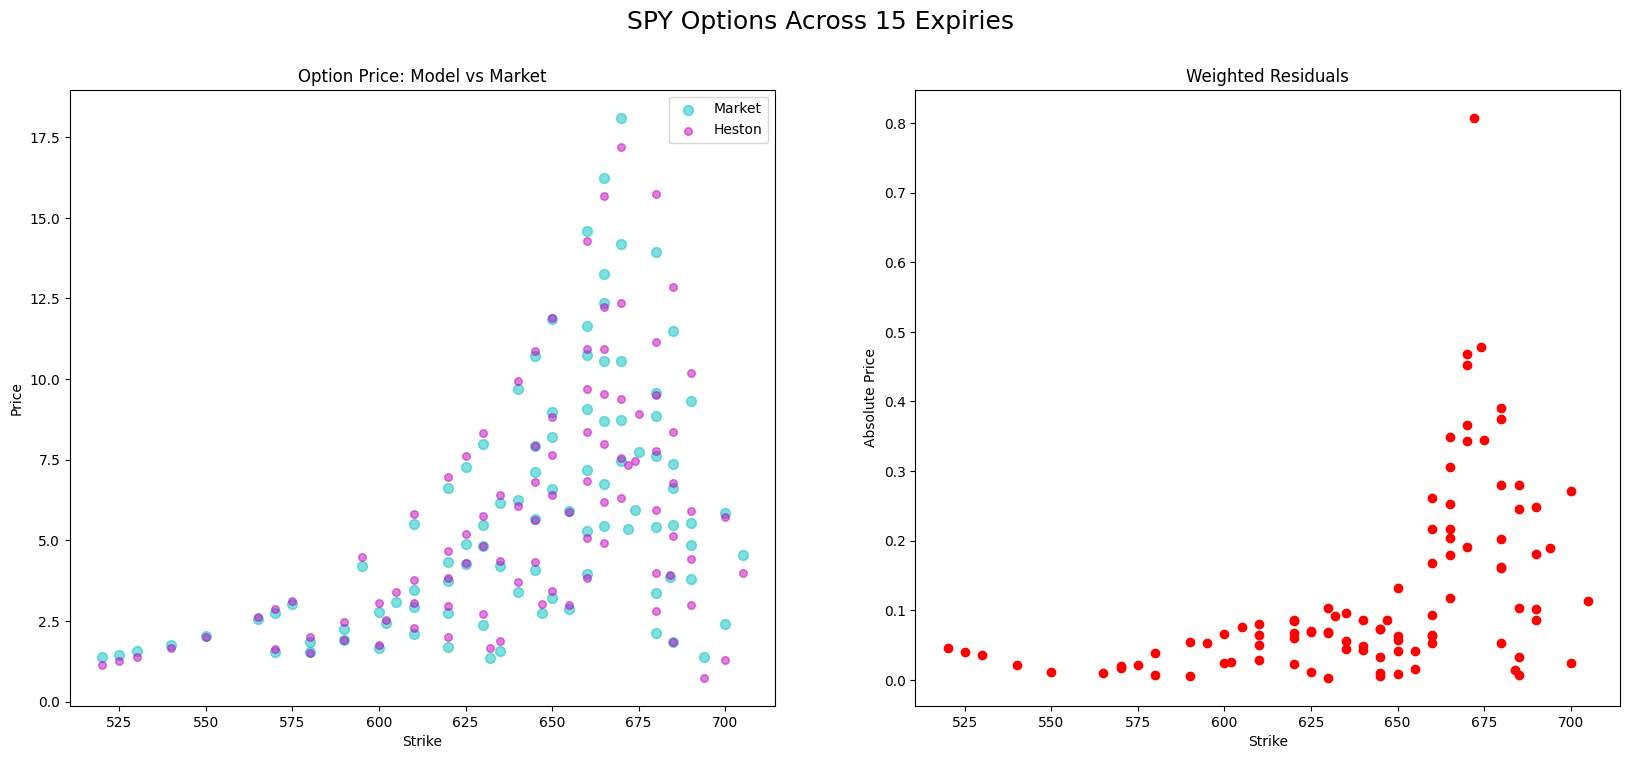

In [25]:
plot_prices(panel_fit, TICKER, N_EXP)

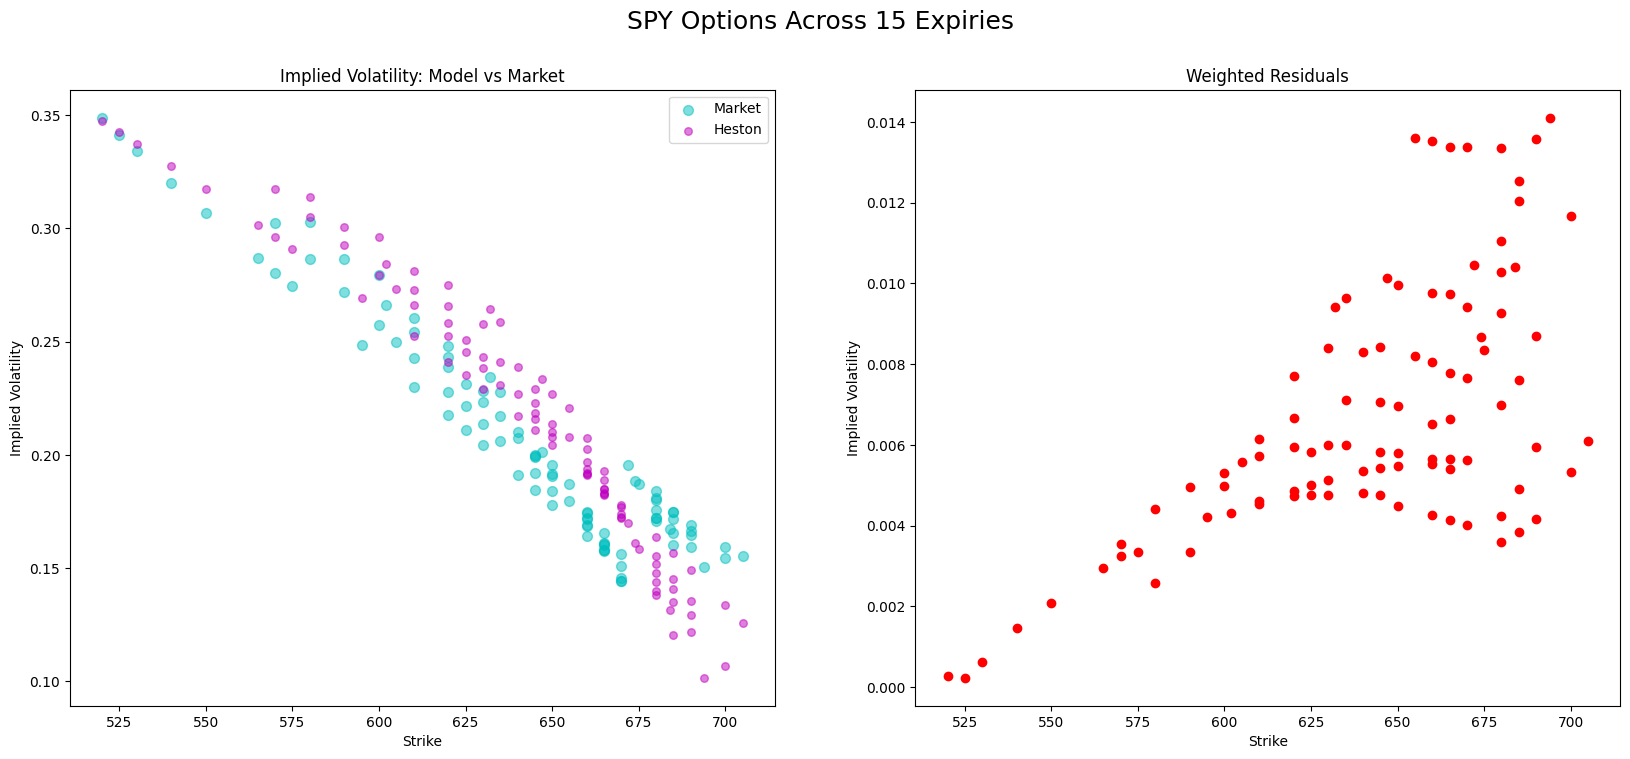

In [ ]:
plot_iv(panel_fit, TICKER, N_EXP)

In [ ]:
def QESim(S0, V0, rho, theta, sigma, kappa, r, q, dt, T_steps, N_paths, psiC=1.5, gamma1=0.5, gamma2=0.5, Martingale_Correction=True, _show_progress=True):
    """
    Simulates the Heston model using the Quadratic Exponential (QE) scheme.

    Parameters
    ----------
    S0 : float
        Initial stock price.
    V0 : float
        Initial variance.
    rho : float
        Correlation between the two Brownian motions.
    theta : float
        Long-term mean of the variance.
    sigma : float
        Volatility of the variance process (vol of vol).
    kappa : float
        Rate at which variance reverts to theta.
    r : float
        Risk-free interest rate.
    q : float
        Dividend yield.
    dt : float
        Time increment.
    T_steps : int
        Number of time steps.
    N_paths : int
        Number of simulated paths.
    psiC : float, optional
        Threshold parameter for the QE scheme (default is 1.5).
    gamma1 : float, optional
        Gamma parameter for the QE scheme (default is 0.5).
    gamma2 : float, optional
        Gamma parameter for the QE scheme (default is 0.5).
    Martingale_Correction : bool, optional
        If True, applies Martingale correction (default is True).
    _show_progress : bool, optional
        If True, displays progress of the simulation (default is True).

    Returns
    -------
    S : ndarray
        Simulated stock prices, shape (N_paths, T_steps+1).
    V : ndarray
        Simulated variances, shape (N_paths, T_steps+1).

    Notes
    -----
    The function uses Sobol sequences for generating random numbers and the inverse cumulative normal distribution to
    obtain normally distributed random variables. The QE scheme is used to handle the variance process.
    
    Martingale correction dynamics:
    - When psi <= psiC:
      \[
      K_0^* = -\frac{A b^2 a}{1 - 2 A a} + \frac{1}{2} \log(1 - 2 A a) - (K_1 + \frac{1}{2} K_3) V_{t-1}
      \]
    - When psi > psiC:
      \[
      K_0^* = -\log\left(p + \frac{\beta (1 - p)}{\beta - A}\right) - (K_1 + \frac{1}{2} K_3) V_{t-1}
      \]

    Examples
    --------
    S_T_array_QE, V_T_array_QE = QESim(S0=100, V0=0.04, rho=-0.7, theta=0.04, sigma=0.2, kappa=1.5, r=0.05, q=0.02, dt=1/252,
                                       T_steps=252, N_paths=10000, Martingale_Correction=True)

    References
    ----------
    Andersen, L. (2008). Simple and efficient simulation of the Heston stochastic volatility model. Journal of Computational Finance, 11(3), 1-42.
    """
    E = np.exp(-kappa * dt)
    K0 = -(kappa * rho * theta) / sigma * dt
    K1 = (kappa * rho / sigma - 1 / 2) * gamma1 * dt - rho / sigma
    K2 = (kappa * rho / sigma - 1 / 2) * gamma2 * dt + rho / sigma
    K3 = (1 - rho ** 2) * gamma1 * dt
    K4 = (1 - rho ** 2) * gamma2 * dt
    A = K2 + 0.5 * K4
    if Martingale_Correction: K0_star = np.empty(N_paths)


    sobol_gen = qmc.Sobol(d=T_steps + 1)
    Uv = sobol_gen.random(n=N_paths).T
    Us = sobol_gen.random(n=N_paths).T
    Zv, Zs = norm.ppf(Uv), norm.ppf(Us)

    S = np.zeros((T_steps+1, N_paths))
    V = np.zeros((T_steps+1, N_paths))

    S[0] = log(S0)
    V[0] = V0

    for t in trange(1, T_steps+1, desc="Simulating Paths", position=0, leave=False, disable=not _show_progress):
        m = theta + (V[t - 1] - theta) * E
        s2 = (V[t - 1] * sigma**2 * E)/kappa * (1 - E) + (theta * sigma**2)/(2 * kappa)*(1 - E)**2 # Correct
        psi = s2 / m ** 2

        idx = psi <= psiC
        # When psi <= psiC
        b = np.sqrt(2/psi[idx] - 1 + np.sqrt(2/psi[idx] * (2/psi[idx] - 1)))
        a = m[idx] / (1 + b**2)     
        V[t, idx] = a * (b + Zv[t, idx]) ** 2

        # When psi > psiC
        p = (psi[~idx] - 1) / (psi[~idx] + 1)
        beta = (1 - p ) / m[~idx]
        idx2 = (Uv[t, ~idx] <= p)
        V[t, ~idx] = np.where(idx2, 0, 1 / beta * np.log((1 - p) / (1 - Uv[t, ~idx])))

        if Martingale_Correction:
            K0_star[idx]  = - (A * b**2 * a) / (1 - 2 * A * a) + 0.5 * np.log(1 - 2 * A * a) - (K1 + 0.5 * K3) * V[t-1, idx]
            K0_star[~idx] = - np.log(p + (beta * (1 - p)) / (beta - A)) - (K1 + 0.5 * K3) * V[t-1, ~idx]

            S[t] = S[t - 1] + (r - q) * dt + K0_star + K1 * V[t - 1] + K2 * V[t] + np.sqrt(K3 * V[t - 1] + K4 * V[t]) * Zs[t]
        else:
            S[t] = S[t - 1] + (r - q) * dt + K0      + K1 * V[t - 1] + K2 * V[t] + np.sqrt(K3 * V[t - 1] + K4 * V[t]) * Zs[t]
    
    S = exp(S).T
    V = V.T

    # Find if there are NaN values and replace those paths with the expectation E[S_t] and E[V_t]
    idx = np.isnan(S).sum(axis=1) == 0
    if idx.sum() < N_paths :
        print(f"Warning: {N_paths - idx.sum()} paths removed due to NaN values and replaced with E[S_t] and E[V_t]")
        S[~idx] = S0*exp((r-q)*np.arange(T_steps+1)*dt)
        V[~idx] = V0 * np.exp(-kappa * np.arange(T_steps+1)*dt) + theta * (1 - np.exp(-kappa * np.arange(T_steps+1)*dt))

    return S, V

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
from typing import Callable, Dict, Iterable

def rolling_param_timeseries(fit_function: Callable[[pd.DataFrame], dict[str, float]], 
                             daily_option_data: Iterable[tuple[pd.Timestamp, pd.DataFrame]]) -> pd.DataFrame:
    """
    Apply existing calibration function over a rolling daily iterator of option surfaces.

    Args:
        fit_function (Callable[[pd.DataFrame], dict[str, float]]):
            Calibration function that takes in an option surface pd.DataFrame as an input and 
            returns a dictionary containing the fitted Heston parameters (kappa, theta, sigma, rho, v0).
        daily_option_data (Iterable[tuple[pd.Timestamp, pd.DataFrame]]):    
            Iterable of (date, df) pairs where each df is one day’s option surface containing the 
            corresponding strikes, maturities, prices, IVs, etc.
    
    Returns:
        pd.DataFrame containing a time-series of fitted Heston parameters with columns for each parameter 
        (kappa, theta, sigma, rho, v0), indexed by date.
    """
    rows = []
    for date, df in daily_option_data:
        try:
            res = fit_function(df)
            rows.append({"date": pd.to_datetime(date), **res})
        except Exception as e:
            rows.append({"date": pd.to_datetime(date), 
                         "kappa": np.nan, "theta": np.nan, "sigma": np.nan, "rho": np.nan, "v0": np.nan})
    param_df = pd.DataFrame(rows).set_index('date').sort_index()
    return param_df

def forecast_params_ar1(param_df: pd.DataFrame) -> HestonParams:
    """
    Forecasts each Heston parameter (kappa, theta, sigma, rho, v0) one-step ahead with an AR(1) model.

    Args:
        param_df (pd.DataFrame):    Time-series of fitted Heston parameters with columns for each parameter 
                                    (kappa, theta, sigma, rho, v0), indexed by date.
    
    Returns:
        HestonParams object containing the one-step forecasted parameters.
    """
    forecasts = {}
    for col in ["kappa", "theta", "sigma", "rho", "v0"]:
        param_series = param_df[col].dropna()
        if len(param_series) < 30:
            forecasts[col] = param_series.iloc[-1] if len(param_series) > 0 else np.nan
            continue
        # Fit AR(1) & predict the next point
        model_ar1 = AutoReg(param_series, lags = 1, old_names = False).fit() # can replace with any forecaster (EWMA, HMM regime switches, etc.)
        param_pred = float(model_ar1.predict(start = len(param_series), end = len(param_series))[0])
        # Enforce model-validity bounds
        if col in ("kappa", "theta", "sigma", "v0"):
            param_pred = max(param_pred, 1e-6) # must be >=0
        if col == "rho":
            param_pred = float(np.clip(param_pred, -0.999, 0.999))
        forecasts[col] = param_pred
    return HestonParams(**forecasts)


In [ ]:
def forecast_on_grid(params: HestonParams, panel_df: Optional[pd.DataFrame] = None, fwd_grid: Optional[pd.DataFrame] = None, 
                     forecast_date: Optional[pd.Timestamp] = None) -> pd.DataFrame:
    """
    Forecast prices & implied volatilities on a node grid using the provided Heston parameters.

    Args:
        params (HestonParams):                      Parameters to build the Heston engine for forecasting.
        panel_df (Optional[pd.DataFrame]):          Universe-snapped panel for one day of chains data. Must include:
                                                    ['symbol','days_to_exp','moneyness','underlying','rate','q','date'].
                                                    If fwd_grid is None, this is used to build the node grid and fundamentals.
        fwd_grid (Optional[pd.DataFrame]):          Forward grid (symbol × days_to_exp × moneyness + spot/r/q) to price.
                                                    If provided, panel_df is ignored for grid construction.
        forecast_date (Optional[pd.Timestamp]):     Forecast date for a T+1 forecast from today.
                                                    If not passed in, default to panel's max date (normalized UTC).

    Returns:
        pd.DataFrame copy of the forward grid with a new column ('iv_forecast') containing the forecasted IV.
    """
    # Build a forward grid if one wasn't provided 
    if fwd_grid is None:
        if panel_df is None or panel_df.empty:
            raise ValueError("Provide either fwd_grid or a non-empty panel_df.")
        fwd_grid = build_forward_grid_from_panel(panel_df)
    # Ensure required columns exist
    required = {"symbol", "days_to_exp", "moneyness", "spot", "rate", "div_yield"}
    missing = required - set(fwd_grid.columns)
    if missing:
        raise KeyError(f"fwd_grid is missing columns: {sorted(missing)}")
    # Normalize date column
    if "date" not in fwd_grid.columns:
        fwd_grid = fwd_grid.copy()
        fwd_grid["date"] = pd.Timestamp.today(tz="UTC").normalize()
    else:
        fwd_grid = fwd_grid.copy()
        fwd_grid["date"] = pd.to_datetime(fwd_grid["date"], utc=True).dt.floor("D")
    
    # ---- Use the QL-based forecast_surface we wired earlier ----
    iv_fc_df = forecast_surface(params, fwd_grid)
        
    

In [ ]:
def forecast_surface(params: HestonParams, fwd_grid: pd.DataFrame) -> pd.DataFrame:
    """
    Build a Heston pricing engine using the provided parameters and compute model-derived prices & 
    implied volatilities on the nodes in the forward grid panel.

    Args:
        params (HestonParams):      Forecasted parameters to build the Heston pricing engine.
        fwd_grid (pd.DataFrame):    Forward grid panel (symbol × days_to_exp × moneyness + spot/r/q) to price.
                                    Must contain the following columns (per row/node):
                                        - 'symbol'          : str (underlying)
                                        - 'days_to_exp'     : int (tenor bins - calendar days)
                                        - 'moneyness'       : float (moneyness bins)
                                        - 'spot'            : float (spot)
                                        - 'rate'            : float (continuous risk-free rate)
                                        - 'q'               : float (continuous dividend yield)
        days_forecast (int):        Number of days to forecast ahead. Default is 1 day.
    
    Returns:
        pd.DataFrame copy of the forward grid with a new column ('iv_forecast') containing the forecasted IV.
    """
    if fwd_grid.empty:
        raise ValueError("Provide a non-empty fwd_grid.")
    # Ensure required columns exist
    required = {"symbol", "days_to_exp", "moneyness", "spot", "rate", "q"}
    missing = required - set(fwd_grid.columns)
    if missing:
        raise KeyError(f"fwd_grid missing required columns: {sorted(missing)}")
    
    # Work on a copy so you don’t mutate the caller’s DataFrame.
    fwd_grid_df = fwd_grid.copy()

    # TODO: TODAY'S DATE -- REMOVE ??
    if "date" not in fwd_grid_df.columns:
        date_today = pd.Timestamp.today(tz = "UTC").normalize()
        fwd_grid_df["date"] = date_today
    else:
        fwd_grid_df["date"] = pd.to_datetime(fwd_grid_df["date"], utc = True)

    # TODO: FORECAST DATE

    # FORECASTED PARAMETERS
    kappa, theta, sigma, rho, v0 = params.kappa, params.theta, params.sigma, params.rho, params.v0

    # Forecast per (symbol, spot, r, q, date) group
    group_keys = ["symbol", "spot", "rate", "q", "date"]
    price_list = []
    iv_list = []
    for _, group_df in fwd_grid_df.groupby(group_keys, sort = False):
        date_pd = pd.to_datetime(group_df["date"].iloc[0]).tz_convert("UTC")
        today_ql = ql.Date(date_pd.day, date_pd.month, date_pd.year)
        ql.Settings.instance().evaluationDate = today_ql
        # cal = ql.UnitedStates(ql.UnitedStates.NYSE)
        
        symbol = group_df["symbol"].iloc[0]
        S_val  = float(group_df["spot"].iloc[0])
        r_val  = float(group_df["rate"].iloc[0])
        q_val  = float(group_df["q"].iloc[0])
        
        S_q = ql.QuoteHandle(ql.SimpleQuote(S_val))
        day_count = ql.Actual365Fixed()
        r_ts = ql.YieldTermStructureHandle(ql.FlatForward(today_ql, r_val, day_count, ql.Continuous))
        q_ts = ql.YieldTermStructureHandle(ql.FlatForward(today_ql, q_val, day_count, ql.Continuous))
        
        _, heston_engine = build_heston_engine(S_q, r_ts, q_ts, kappa, theta, sigma, rho, v0)

        group_option_chains_df = pd.DataFrame({
            
        })

        df_g = pd.DataFrame({
            "date":   g["date"].values,
            "expiry": (g["date"] + pd.to_timedelta(g["days_to_exp"].astype(int), unit="D")).values,
            "type":   ["call"] * len(g),  # call vs put doesn't change IV for same K under parity
            "strike": (g["moneyness"] * g["spot"]).astype(float).values
        })
        

In [ ]:

def forecast_surface(params: HestonParams, fwd_grid: pd.DataFrame) -> pd.DataFrame:
    """
    Build a Heston engine from the provided params and compute model-implied IVs
    on the nodes in `fwd_grid` using your QuantLib helpers.

    Expected fwd_grid columns (per row/node):
      - 'symbol'        : str (ok if single name; still kept)
      - 'days_to_exp'   : int (calendar days)
      - 'moneyness'     : float (K/S)
      - 'spot'          : float (S)
      - 'rate'          : float (continuous r)
      - 'q'             : float (continuous dividend yield)
      - optional 'date' : timestamp; if absent, today's date is used

    Returns: fwd_grid copy with a new column 'iv_fc' (decimal IV).
    """

    if fwd_grid.empty:
        return fwd_grid.assign(iv_fc=np.nan)

    out = fwd_grid.copy()

    # Normalize/ensure required columns exist and are of proper dtypes
    required = {"symbol", "days_to_exp", "moneyness", "spot", "rate", "q"}
    missing = required - set(out.columns)
    if missing:
        raise KeyError(f"fwd_grid missing required columns: {sorted(missing)}")

    # If no 'date', use today's date; otherwise take the most recent date per group
    if "date" not in out.columns:
        today_pd = pd.Timestamp.today(tz="UTC").normalize()
        out["date"] = today_pd
    else:
        out["date"] = pd.to_datetime(out["date"], utc=True)

    # We’ll compute per (symbol, spot, rate, q, date) group to avoid rebuilding handles per row
    group_keys = ["symbol", "spot", "rate", "q", "date"]
    iv_list = []

    # Prepare the parameter tuple once
    kappa, theta, sigma, rho, v0 = params.kappa, params.theta, params.sigma, params.rho, params.v0

    # Group to reuse curves/handles within each symbol/day/context
    for _, g in out.groupby(group_keys, sort=False):
        symbol = g["symbol"].iloc[0]
        S_val  = float(g["spot"].iloc[0])
        r_val  = float(g["rate"].iloc[0])
        q_val  = float(g["q"].iloc[0])

        # --- Build QL "today" and set evaluation date
        date_pd = pd.to_datetime(g["date"].iloc[0]).tz_convert("UTC")
        ql_today = ql.Date(date_pd.day, date_pd.month, date_pd.year)
        ql.Settings.instance().evaluationDate = ql_today

        # --- Build spot and flat term structures from this group's S/r/q
        S_q  = ql.QuoteHandle(ql.SimpleQuote(S_val))
        day_count = ql.Actual365Fixed()
        r_ts = ql.YieldTermStructureHandle(ql.FlatForward(ql_today, r_val, day_count, ql.Continuous))
        q_ts = ql.YieldTermStructureHandle(ql.FlatForward(ql_today, q_val, day_count, ql.Continuous))

        # --- Build Heston engine with your helper
        _, engine = build_heston_engine(S_q, r_ts, q_ts, kappa, theta, sigma, rho, v0)

        # --- Create a minimal "df" of options for this group, using CALLs (IV is parity-symmetric)
        #     Columns required by your compute_model_prices_and_ivs/model_prices_and_ivs:
        #       ['date','expiry','type','strike'] at minimum, plus we pass handles separately
        df_g = pd.DataFrame({
            "date":   g["date"].values,
            "expiry": (g["date"] + pd.to_timedelta(g["days_to_exp"].astype(int), unit="D")).values,
            "type":   ["call"] * len(g),  # call vs put doesn't change IV for same K under parity
            "strike": (g["moneyness"] * g["spot"]).astype(float).values
        })

        # --- Compute Heston model prices and the corresponding BS implied vols
        #     (Your helper builds a seed BSM process and inverts IV from model price)
        priced = model_prices_and_ivs(df_g, engine, ql_today, S_q, r_ts, q_ts)

        # Collect the IVs in the original row order of the group
        iv_list.append(pd.Series(priced["iv_model"].values, index=g.index))

    # Concatenate per-group IVs and assign to 'iv_fc'
    out["iv_fc"] = pd.concat(iv_list).sort_index()

    return out


In [ ]:
import pandas as pd
import pandas_market_calendars as mcal

def next_trading_day(panel_today: pd.DataFrame, cal_code: str = "XNYS") -> pd.Timestamp:
    """
    Given a universe-snapped panel for today, return the next trading day
    according to the given market calendar (default: NYSE 'XNYS').

    Returns a tz-aware UTC pandas.Timestamp normalized to midnight.
    """
    if panel_today is None or panel_today.empty:
        raise ValueError("panel_today is empty; cannot determine next trading day.")

    # Latest timestamp in the panel (assume this is 'today' in your pipeline)
    last_ts = pd.to_datetime(panel_today["date"].max()).tz_convert("UTC")

    # Build a small window around last_ts to find the next trading session
    cal = mcal.get_calendar(cal_code)
    start = (last_ts - pd.Timedelta(days=5)).date()
    end   = (last_ts + pd.Timedelta(days=10)).date()
    sched = cal.schedule(start_date=start, end_date=end)

    # Convert schedule times to UTC for robust comparison
    sched_utc = sched.copy()
    sched_utc["market_open_utc"]  = sched_utc["market_open"].dt.tz_convert("UTC")
    sched_utc["market_close_utc"] = sched_utc["market_close"].dt.tz_convert("UTC")

    # Sessions strictly after the last timestamp in the panel
    future = sched_utc[sched_utc["market_open_utc"] > last_ts]
    if future.empty:
        raise RuntimeError("Could not find a future trading session in the given window.")

    next_open_utc = future["market_open_utc"].iloc[0]

    # Normalize to midnight UTC for use as a forecast_date
    return next_open_utc.normalize()


In [ ]:
def forecast_iv_on_grid(
    params: HestonParams,
    panel_today: Optional[pd.DataFrame] = None,
    fwd_grid: Optional[pd.DataFrame] = None,
    forecast_date: Optional[pd.Timestamp] = None,
) -> pd.DataFrame:
    """
    Forecast IVs on a node grid using the provided Heston parameters.
    You can either:
      (A) pass an explicit fwd_grid with columns
          ['symbol','days_to_exp','moneyness','spot','rate','q', (optional) 'date']
      or
      (B) pass a panel_today (universe-snapped) and this function will build a minimal fwd_grid
          from its nodes and fundamentals.

    Parameters
    ----------
    params : HestonParams
        Parameters to use when building the Heston engine for forecasting.
    panel_today : DataFrame, optional
        If fwd_grid is None, this is used to build the node grid and fundamentals.
        Must include ['symbol','days_to_exp','moneyness','underlying','rate','div_yield','date'].
    fwd_grid : DataFrame, optional
        Explicit forward grid to price. If provided, panel_today is ignored for grid construction.
    forecast_date : pd.Timestamp, optional
        If building from panel_today and you want a T+1 forecast, pass the forecast date.
        Otherwise, defaults to panel_today's max date (normalized UTC).

    Returns
    -------
    iv_fc_df : DataFrame
        Copy of the grid with a new 'iv_fc' column (forecasted IV, decimal).
    """
    # ---- Build a grid if one wasn't provided ----
    if fwd_grid is None:
        if panel_today is None or panel_today.empty:
            raise ValueError("Provide either fwd_grid or a non-empty panel_today.")

        # Use the latest calendar day in the panel
        latest_day = pd.to_datetime(panel_today["date"], utc=True).dt.floor("D").max()
        use_date = pd.to_datetime(forecast_date, utc=True).floor("D") if forecast_date is not None else latest_day

        nodes = (panel_today[["symbol","days_to_exp","moneyness"]]
                 .drop_duplicates()
                 .sort_values(["symbol","days_to_exp","moneyness"]))

        spot_map = panel_today.groupby("symbol")["underlying"].last().to_dict()
        rate_map = panel_today.groupby("symbol")["rate"].last().to_dict()
        divy_map = panel_today.groupby("symbol")["div_yield"].last().to_dict()

        fwd_grid = nodes.copy()
        fwd_grid["spot"] = fwd_grid["symbol"].map(spot_map)
        fwd_grid["rate"] = fwd_grid["symbol"].map(rate_map)
        fwd_grid["q"]    = fwd_grid["symbol"].map(divy_map)
        fwd_grid["date"] = use_date

    # ---- Ensure required columns exist ----
    required = {"symbol","days_to_exp","moneyness","spot","rate","q"}
    missing = required - set(fwd_grid.columns)
    if missing:
        raise KeyError(f"fwd_grid is missing columns: {sorted(missing)}")

    # ---- Normalize date column ----
    if "date" not in fwd_grid.columns:
        fwd_grid = fwd_grid.copy()
        fwd_grid["date"] = pd.Timestamp.today(tz="UTC").normalize()
    else:
        fwd_grid = fwd_grid.copy()
        fwd_grid["date"] = pd.to_datetime(fwd_grid["date"], utc=True).dt.floor("D")

    # ---- Use the QL-based forecast_surface we wired earlier ----
    iv_fc_df = forecast_surface(params, fwd_grid)

    # (Optional) sanity checks: fill impossible values with NaN
    iv_fc_df.loc[~np.isfinite(iv_fc_df["iv_fc"]) | (iv_fc_df["iv_fc"] <= 0), "iv_fc"] = np.nan
    return iv_fc_df


In [ ]:
from __future__ import annotations

import numpy as np
import pandas as pd
import QuantLib as ql
from dataclasses import dataclass
from typing import Optional, Tuple

# Re-state for clarity (or import from where you defined it)
@dataclass
class HestonParams:
    kappa: float
    theta: float
    sigma: float
    rho: float
    v0: float


def fit_heston_on_panel_today(
    panel_today: pd.DataFrame,
    lambda_wing: float,
    param_lb: list[float],
    param_ub: list[float],
    use_otm_only: bool = True,
) -> Tuple[HestonParams, ql.AnalyticHestonEngine, pd.DataFrame, float]:
    """
    Fit a Heston model on today's universe-snapped panel and compute model prices/IVs
    (on the calibration subset) along with diagnostics.

    Assumes a single underlying symbol in panel_today. If multiple symbols are present,
    run this per symbol (groupby and call inside a loop).

    Parameters
    ----------
    panel_today : DataFrame
        Must contain (at least):
        ['date','type','strike','underlying','rate','div_yield','mid','iv_mkt',
         'volume','open_interest','days_to_exp','moneyness','expiry']
        plus whatever your helpers expect (e.g., 'T' if you precomputed it; if not, we compute below).
    lambda_wing : float
        Wing damping parameter for calibration weighting.
    param_lb, param_ub : list[float]
        Bounds for [kappa, theta, sigma, rho, v0].
    use_otm_only : bool
        If True, restrict calibration to OTM puts (K<=S) and OTM calls (K>=S).

    Returns
    -------
    params_today : HestonParams
        Fitted parameters (today).
    engine_cal : ql.AnalyticHestonEngine
        Calibrated Heston engine (today).
    df_fit_out : DataFrame
        Calibration subset with added columns:
        ['bs_price','vega','w_iv','w_wing','w','w_norm','price_model','iv_model','price_resid','iv_resid'].
    price_rmse : float
        Price RMSE on the calibration subset.
    """
    if panel_today.empty:
        raise ValueError("panel_today is empty.")

    # ---- Evaluation date (use the latest date in the panel) ----
    date_pd = pd.to_datetime(panel_today["date"].max()).tz_convert("UTC")
    ql_today = ql.Date(date_pd.day, date_pd.month, date_pd.year)
    ql.Settings.instance().evaluationDate = ql_today

    # ---- Pull fundamentals (single symbol assumed) ----
    S0 = float(panel_today["underlying"].iloc[-1])
    r  = float(panel_today["rate"].iloc[-1])
    q  = float(panel_today["div_yield"].iloc[-1])

    # ---- QuantLib handles ----
    S_quote = ql.QuoteHandle(ql.SimpleQuote(S0))
    dc      = ql.Actual365Fixed()
    r_curve = ql.YieldTermStructureHandle(ql.FlatForward(ql_today, r, dc, ql.Continuous))
    q_curve = ql.YieldTermStructureHandle(ql.FlatForward(ql_today, q, dc, ql.Continuous))

    # ---- Calibration subset (optionally OTM only) ----
    df_fit = panel_today.copy()
    if use_otm_only:
        mask = (
            (df_fit["type"].str.lower().str.startswith("p") & (df_fit["strike"] <= S0)) |
            (df_fit["type"].str.lower().str.startswith("c") & (df_fit["strike"] >= S0))
        )
        df_fit = df_fit.loc[mask].copy()

    # Ensure time to expiry in years (T) and forward F for weighting
    if "T" not in df_fit.columns:
        df_fit["T"] = df_fit["days_to_exp"].astype(float) / 365.0
    if "F" not in df_fit.columns:
        df_fit["F"] = df_fit["underlying"] * np.exp((df_fit["rate"] - df_fit["div_yield"]) * df_fit["T"])

    # ---- Instruments & BS greeks for inverse-variance weighting ----
    opts_list = build_vanilla_instruments(df_fit, ql_today)
    df_fit = bs_price_vega(df_fit, opts_list, S_quote, r_curve, q_curve)

    # ---- Calibration weights (wing & IV-variance), normalized per expiry ----
    df_fit = calibration_weighting(df_fit, lambda_wing)
    # After filtering/weighting, rebuild option list to match current df_fit order
    opts_list = build_vanilla_instruments(df_fit, ql_today)

    # ---- Fit Heston via your least-squares routine ----
    kappa, theta, sigma, rho, v0 = fit_heston_ls(df_fit, opts_list, S_quote, r_curve, q_curve, param_lb, param_ub)

    # ---- Build calibrated engine & diagnostics ----
    _, engine_cal = build_heston_engine(S_quote, r_curve, q_curve, kappa, theta, sigma, rho, v0)
    price_rmse = compute_price_rmse(df_fit, opts_list, engine_cal)

    # ---- Compute model prices & IVs on the calibration set, plus residuals ----
    df_fit = model_prices_and_ivs(df_fit, engine_cal, ql_today, S_quote, r_curve, q_curve)
    df_fit = compute_residuals(df_fit)

    params_today = HestonParams(kappa=kappa, theta=theta, sigma=sigma, rho=rho, v0=v0)
    return params_today, engine_cal, df_fit, float(price_rmse)


def forecast_iv_on_grid(
    params: HestonParams,
    panel_today: Optional[pd.DataFrame] = None,
    fwd_grid: Optional[pd.DataFrame] = None,
    forecast_date: Optional[pd.Timestamp] = None,
) -> pd.DataFrame:
    """
    Forecast IVs on a node grid using the provided Heston parameters.
    You can either:
      (A) pass an explicit fwd_grid with columns
          ['symbol','days_to_exp','moneyness','spot','rate','q', (optional) 'date']
      or
      (B) pass a panel_today (universe-snapped) and this function will build a minimal fwd_grid
          from its nodes and fundamentals.

    Parameters
    ----------
    params : HestonParams
        Parameters to use when building the Heston engine for forecasting.
    panel_today : DataFrame, optional
        If fwd_grid is None, this is used to build the node grid and fundamentals.
        Must include ['symbol','days_to_exp','moneyness','underlying','rate','div_yield','date'].
    fwd_grid : DataFrame, optional
        Explicit forward grid to price. If provided, panel_today is ignored for grid construction.
    forecast_date : pd.Timestamp, optional
        If building from panel_today and you want a T+1 forecast, pass the forecast date.
        Otherwise, defaults to panel_today's max date (normalized UTC).

    Returns
    -------
    iv_fc_df : DataFrame
        Copy of the grid with a new 'iv_fc' column (forecasted IV, decimal).
    """
    # ---- Build a grid if one wasn't provided ----
    if fwd_grid is None:
        if panel_today is None or panel_today.empty:
            raise ValueError("Provide either fwd_grid or a non-empty panel_today.")

        # Use the latest calendar day in the panel
        latest_day = pd.to_datetime(panel_today["date"], utc=True).dt.floor("D").max()
        use_date = pd.to_datetime(forecast_date, utc=True).floor("D") if forecast_date is not None else latest_day

        nodes = (panel_today[["symbol","days_to_exp","moneyness"]]
                 .drop_duplicates()
                 .sort_values(["symbol","days_to_exp","moneyness"]))

        spot_map = panel_today.groupby("symbol")["underlying"].last().to_dict()
        rate_map = panel_today.groupby("symbol")["rate"].last().to_dict()
        divy_map = panel_today.groupby("symbol")["div_yield"].last().to_dict()

        fwd_grid = nodes.copy()
        fwd_grid["spot"] = fwd_grid["symbol"].map(spot_map)
        fwd_grid["rate"] = fwd_grid["symbol"].map(rate_map)
        fwd_grid["q"]    = fwd_grid["symbol"].map(divy_map)
        fwd_grid["date"] = use_date

    # ---- Ensure required columns exist ----
    required = {"symbol","days_to_exp","moneyness","spot","rate","q"}
    missing = required - set(fwd_grid.columns)
    if missing:
        raise KeyError(f"fwd_grid is missing columns: {sorted(missing)}")

    # ---- Normalize date column ----
    if "date" not in fwd_grid.columns:
        fwd_grid = fwd_grid.copy()
        fwd_grid["date"] = pd.Timestamp.today(tz="UTC").normalize()
    else:
        fwd_grid = fwd_grid.copy()
        fwd_grid["date"] = pd.to_datetime(fwd_grid["date"], utc=True).dt.floor("D")

    # ---- Use the QL-based forecast_surface we wired earlier ----
    iv_fc_df = forecast_surface(params, fwd_grid)

    # (Optional) sanity checks: fill impossible values with NaN
    iv_fc_df.loc[~np.isfinite(iv_fc_df["iv_fc"]) | (iv_fc_df["iv_fc"] <= 0), "iv_fc"] = np.nan
    return iv_fc_df


In [ ]:
# Next (when ready):
#   params_hat = ar1_forecast_params(param_df)   # from the scaffold
#   iv_fc = forecast_surface(heston_iv, params_hat, fwd_grid)
#   current_iv = panel.groupby(["symbol","days_to_exp","moneyness"], as_index=False)["iv_mkt"].mean()
#   signals_df = current_iv.merge(iv_fc, on=["symbol","days_to_exp","moneyness"], how="inner")
#   signals_df["signal_raw"] = signals_df["iv_fc"] - signals_df["iv_mkt"]